## KLASIFIKASI JENIS JAMUR AGARICUS DAN AMANITA MENGGUNAKAN EKSTRAKSI FITUR GLCM DAN METODE KNN, SVM, SERTA RANDOM FOREST

#### Import Library

In [14]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns
import random

In [23]:
import os

DATASET_PATH  = 'dataset'
N_PER_LABEL = 70

LABELS = {
    'AG'    : 'Agaricus',
    'AM' : 'Amanita'
}

def load_images_from_folder(folder_path, n):
    images, filenames = [], []
    
    if not os.path.exists(folder_path):
        print(f"Peringatan: Folder {folder_path} tidak ditemukan!")
        return images, filenames
    
    files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg', 'jpeg', 'png'))
    ])[:n]

    for fname in files:
        img = cv.imread(os.path.join(folder_path, fname))
        if img is not None:
            images.append(img)
            filenames.append(fname)

    return images, filenames

data = {}
for label, subfolder in LABELS.items():
    folder_path = os.path.join(DATASET_PATH, subfolder)
    imgs, fnames = load_images_from_folder(folder_path, N_PER_LABEL)
    data[label] = {'images': imgs, 'filenames': fnames}
    
    print(f"Berhasil memuat {len(imgs)} gambar untuk kategori: {label}")

Berhasil memuat 70 gambar untuk kategori: AG
Berhasil memuat 70 gambar untuk kategori: AM


--- PROSES RESIZE CITRA JAMUR ---
Kategori AG: Selesai meresize 70 gambar ke ukuran (480, 640)
Kategori AM: Selesai meresize 70 gambar ke ukuran (480, 640)

--- MENAMPILKAN 6 GAMBAR HASIL RESIZE ---
Gambar 1: Nama = Agaricus augustus_204.jpg | Label = AG | Ukuran Baru = (640, 480, 3)
Gambar 2: Nama = Agaricus_subrufescens_000003_0.jpg | Label = AG | Ukuran Baru = (640, 480, 3)
Gambar 3: Nama = Amanita_phalloides_000006_1.jpg | Label = AM | Ukuran Baru = (640, 480, 3)
Gambar 4: Nama = Agaricus xanthodermus_45.jpg | Label = AG | Ukuran Baru = (640, 480, 3)
Gambar 5: Nama = Amanita flavoconia_92.jpg | Label = AM | Ukuran Baru = (640, 480, 3)
Gambar 6: Nama = Agaricus xanthodermus_214.jpg | Label = AG | Ukuran Baru = (640, 480, 3)
Gambar 7: Nama = Agaricus augustus_95.jpg | Label = AG | Ukuran Baru = (640, 480, 3)
Gambar 8: Nama = Agaricus augustus_1.jpg | Label = AG | Ukuran Baru = (640, 480, 3)
Gambar 9: Nama = Agaricus xanthodermus_167.jpg | Label = AG | Ukuran Baru = (640, 480, 3)
Gamb

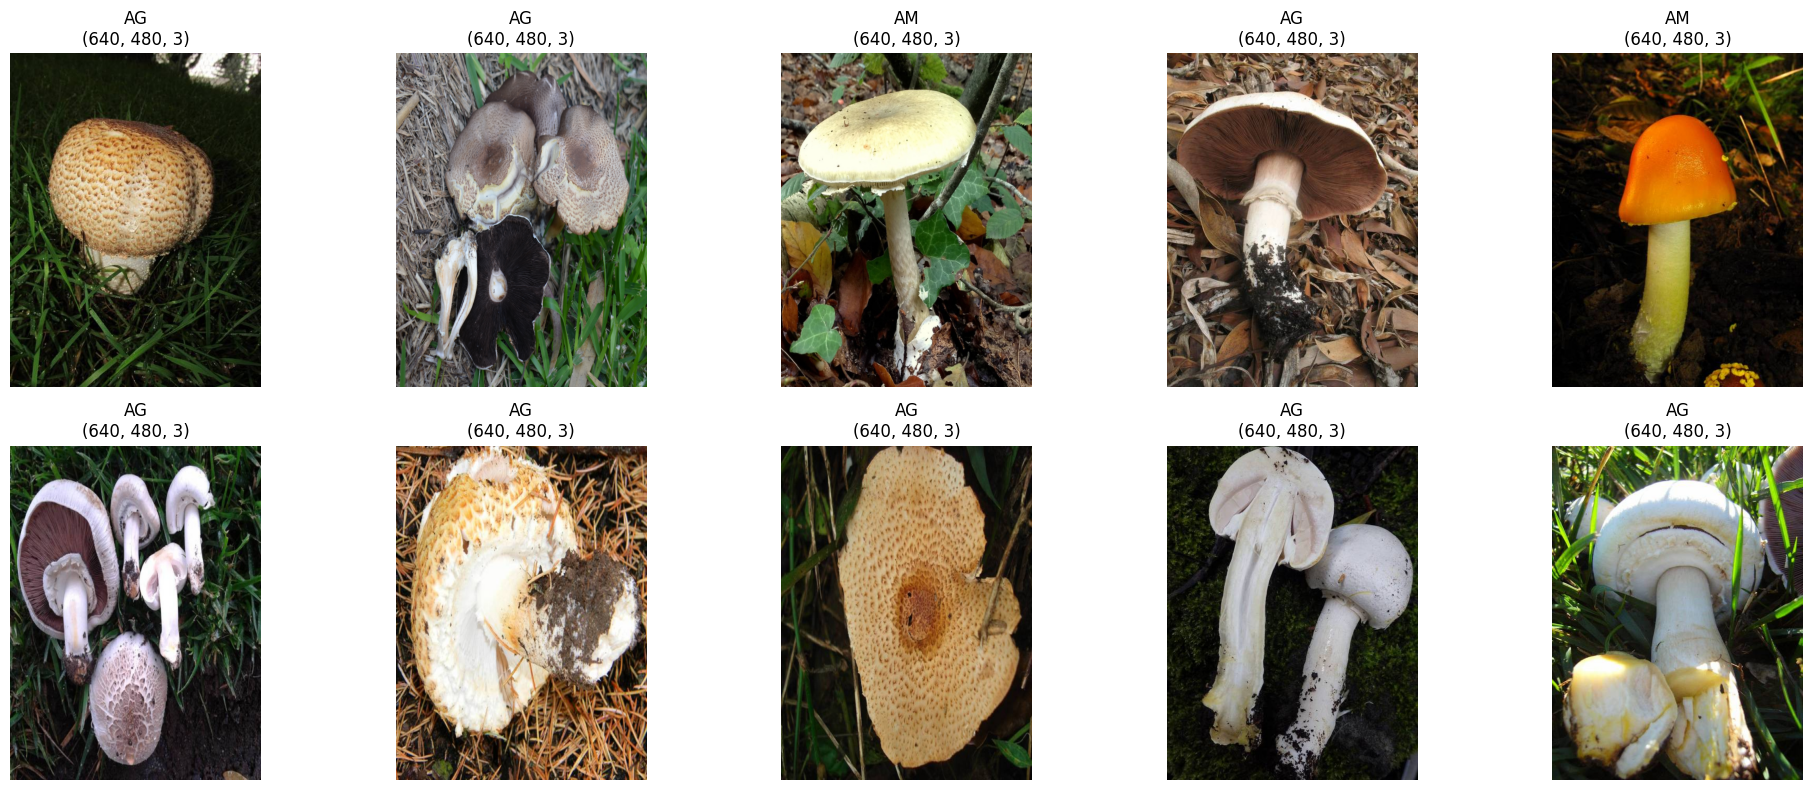

In [24]:
UKURAN_BARU = (480, 640)

data_resized = {}

print("--- PROSES RESIZE CITRA JAMUR ---")

for label, konten in data.items():
    list_gambar_baru = []
    list_nama_baru = []
    
    for img, fname in zip(konten['images'], konten['filenames']):
        img_resized = cv.resize(img, UKURAN_BARU, interpolation=cv.INTER_AREA)
        
        list_gambar_baru.append(img_resized)
        list_nama_baru.append(fname)
        
    data_resized[label] = {
        'images': list_gambar_baru,
        'filenames': list_nama_baru
    }
    print(f"Kategori {label}: Selesai meresize {len(list_gambar_baru)} gambar ke ukuran {UKURAN_BARU}")


print("\n--- MENAMPILKAN 6 GAMBAR HASIL RESIZE ---")

semua_sampel = []
for label, konten in data_resized.items():
    for img, fname in zip(konten['images'], konten['filenames']):
        semua_sampel.append((img, fname, label))

sampel_acak = random.sample(semua_sampel, 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten() 

for i, (img, fname, label) in enumerate(sampel_acak):
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{label}\n{img.shape}")
    axes[i].axis('off') 
    
    print(f"Gambar {i+1}: Nama = {fname} | Label = {label} | Ukuran Baru = {img.shape}")

plt.tight_layout()
plt.show()

In [19]:
def convert_to_grayscale(images):
    """Mengkonversi list gambar BGR ke grayscale menggunakan cv2"""
    return [cv.cvtColor(img, cv.COLOR_BGR2GRAY) for img in images]

# Logika baru: Ambil data dari 'data_resized', lalu masukkan hasil grayscale ke 'data_resized' juga
for label in data_resized:
    data_resized[label]['gray'] = convert_to_grayscale(data_resized[label]['images'])

print("Langkah 2: Selesai mengubah hasil resize menjadi citra grayscale!")

Langkah 2: Selesai mengubah hasil resize menjadi citra grayscale!


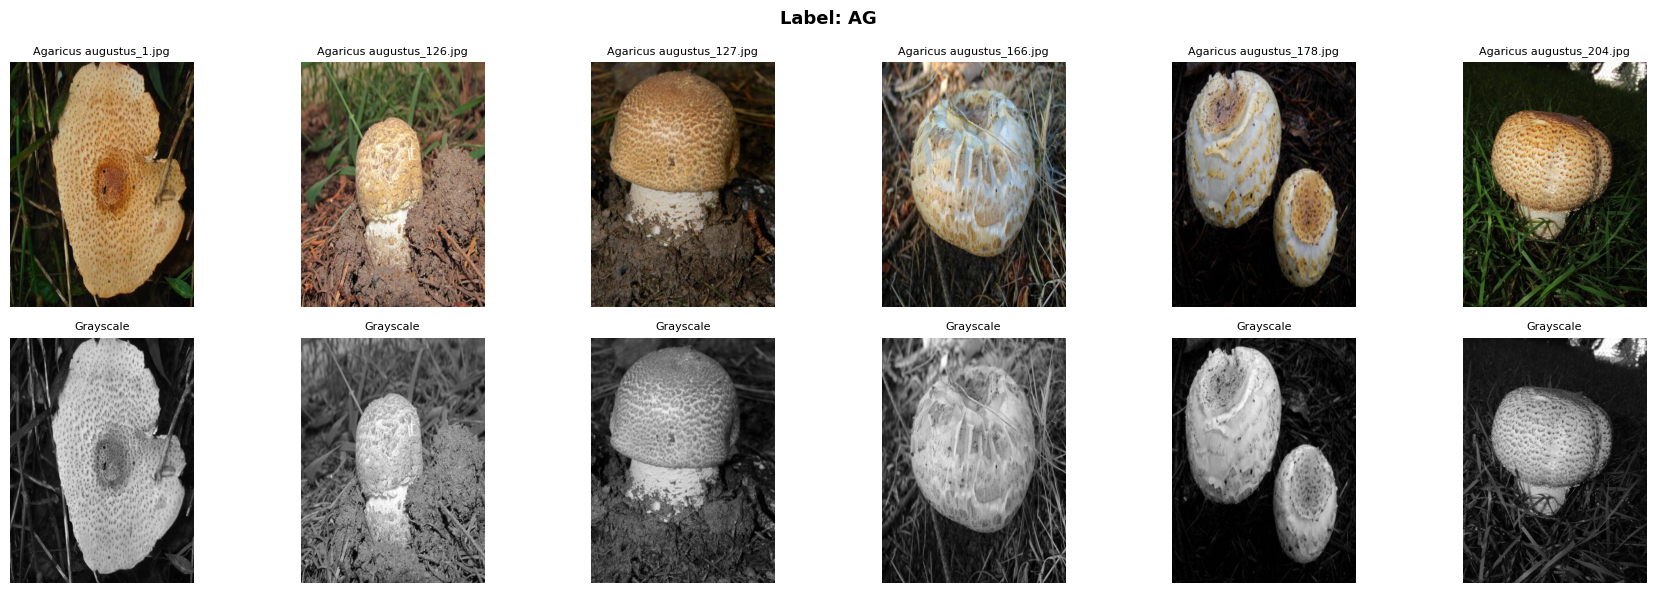

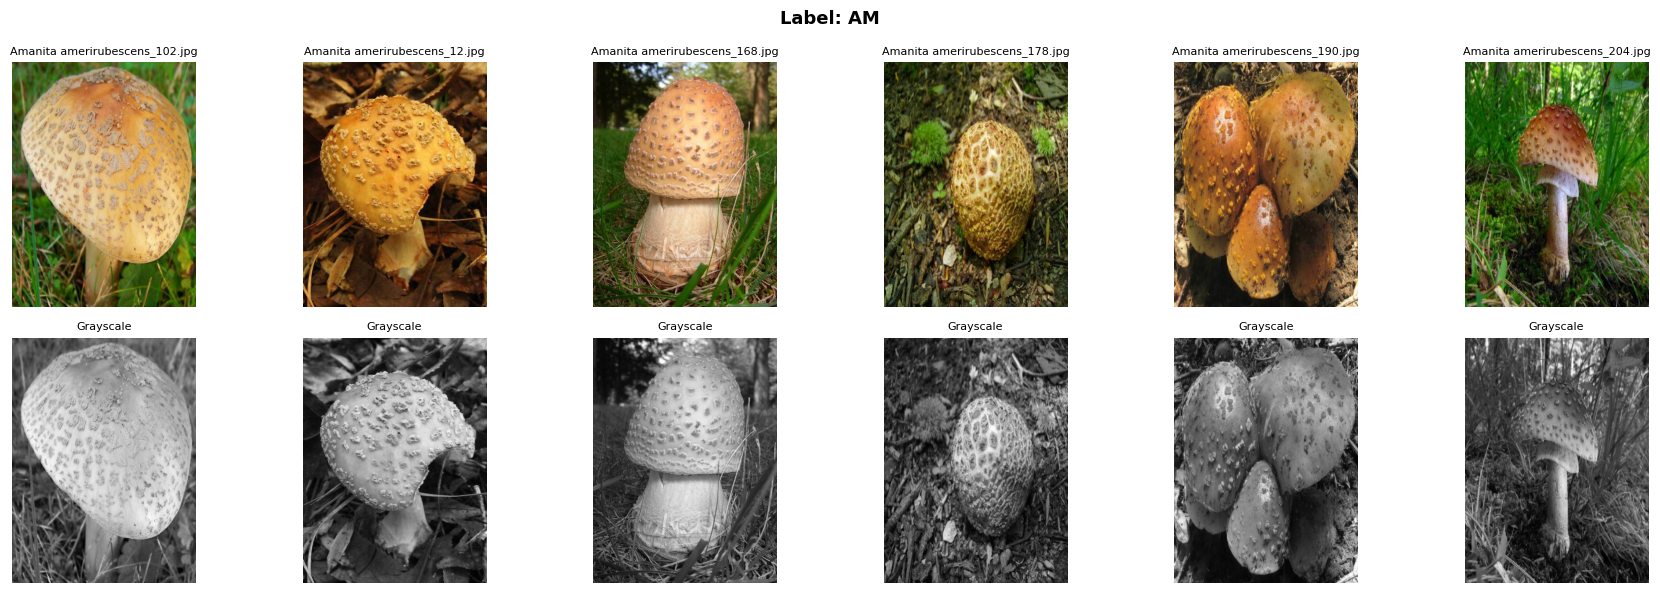

In [20]:
PREVIEW_N = 6

for label in data_resized:
    imgs_bgr  = data_resized[label]['images'][:PREVIEW_N]
    imgs_gray = data_resized[label]['gray'][:PREVIEW_N]
    fnames    = data_resized[label]['filenames'][:PREVIEW_N]

    fig, axes = plt.subplots(2, PREVIEW_N, figsize=(PREVIEW_N * 3, 6))
    fig.suptitle(f'Label: {label}', fontsize=13, fontweight='bold')

    for i in range(PREVIEW_N):
        # Menampilkan gambar BGR hasil resize (dikonversi ke RGB untuk Matplotlib)
        axes[0, i].imshow(cv.cvtColor(imgs_bgr[i], cv.COLOR_BGR2RGB))
        axes[0, i].set_title(fnames[i], fontsize=8)
        axes[0, i].axis('off')

        # Menampilkan gambar Grayscale hasil dari gambar yang di-resize tadi
        axes[1, i].imshow(imgs_gray[i], cmap='gray')
        axes[1, i].set_title('Grayscale', fontsize=8)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()